# Plot Results for the Random Gx/Gx/c Queue Generator

This script generates plots and visual analyses for simulations produced by the random **Gx/Gx/c** queue generator.

### Requirements
- `exp_ggc`

### Authors
- Rafael Andrade  
- Eriky Silva  
- Frederico Cruz  

---

Required packages

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import pickle

### Prepare data for plotting

In [2]:
filename = "sim_2026-04-25.pkl"

with open(filename, 'rb') as f:
    results = pickle.load(f)

df_plot = results['sim_MMx1']
df_plot = df_plot[df_plot['batch'].isin([1, 2, 3])]

### Plotting data

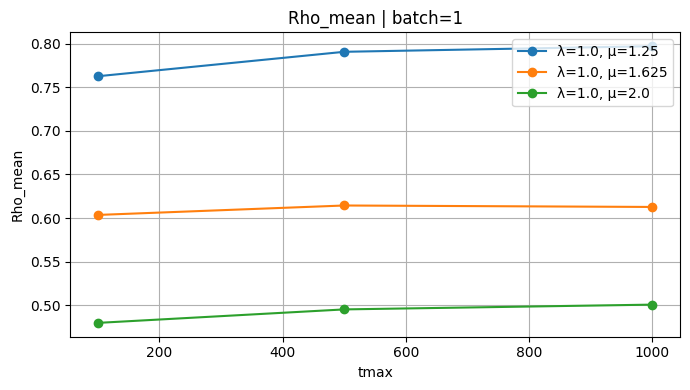

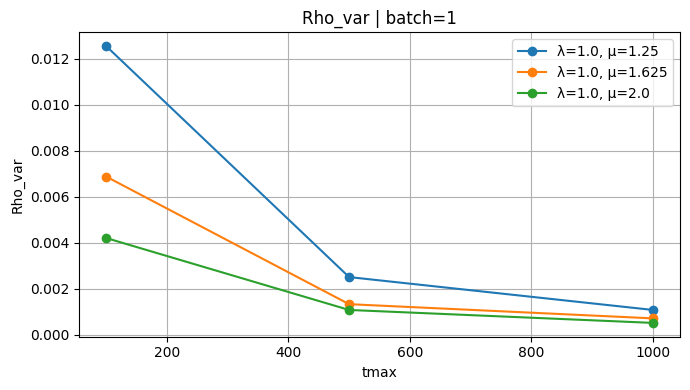

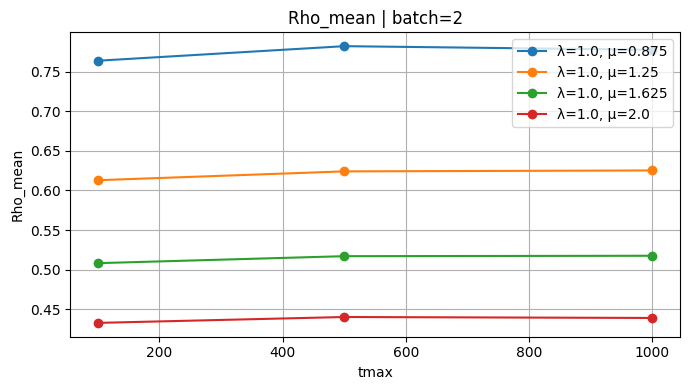

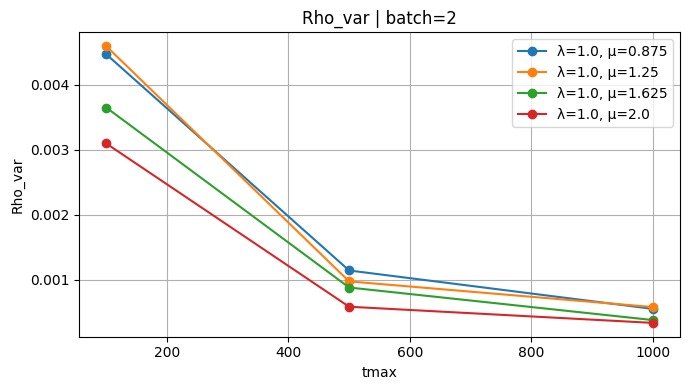

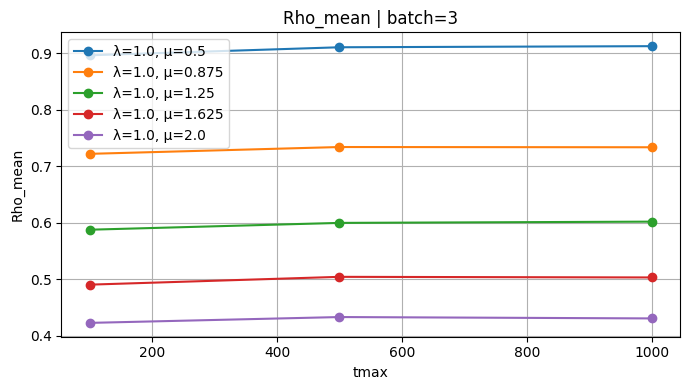

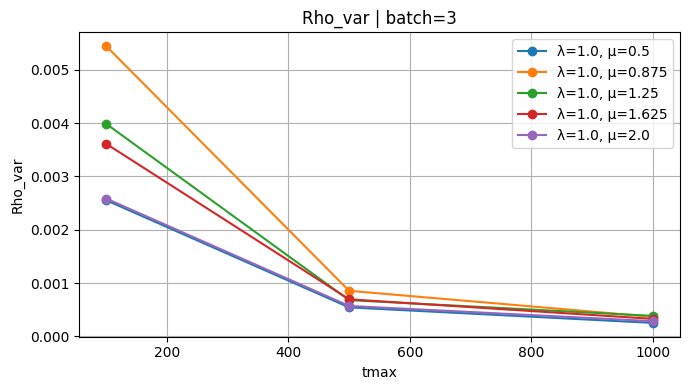

In [3]:
metrics = [
    #'Wq_mean',
    #'Lq_mean',
    'Rho_mean',
    #'Wq_var',
    #'Lq_var',
    'Rho_var'
]

for batch, dfb in df_plot.groupby('batch'):
    for metric in metrics:
        plt.figure(figsize=(7,4))

        for (l, m), sub in dfb.sort_values('tmax').groupby(['lambda', 'mu']):
            if sub['Rho_mean'].max() < 0.98: # so the queue is stable
                plt.plot(sub['tmax'], sub[metric], marker='o', 
                        label=f'λ={l}, μ={m}')

        plt.title(f'{metric} | batch={batch}')
        plt.xlabel('tmax')
        plt.ylabel(metric)
        plt.legend()
        plt.grid()
        plt.tight_layout()
        plt.show()

In [4]:
# Tema e configuracoes

plt.style.use('seaborn-v0_8-white')

plt.rcParams.update({
    'figure.figsize': (7,4),
    'font.size': 11,
    'axes.labelsize': 12,
    'legend.fontsize': 9,
    'lines.linewidth': 2,
    'grid.alpha': 0.3
})

metric_info = {
    'Wq_mean': ('$W_q$', 'Vies'),
    'Wq_var' : ('$W_q$', 'Variancia')
}

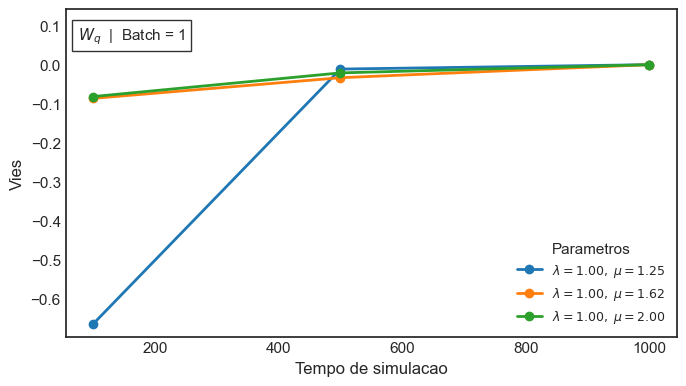

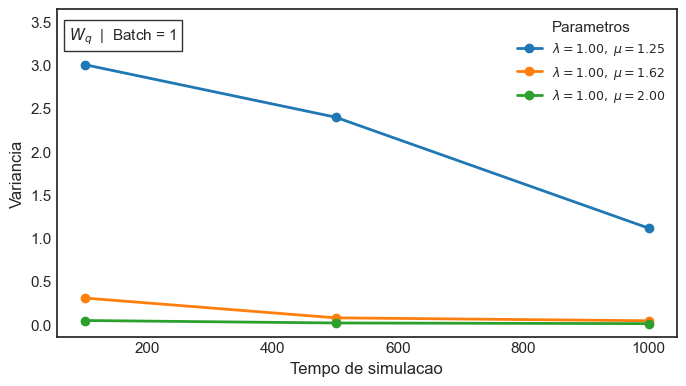

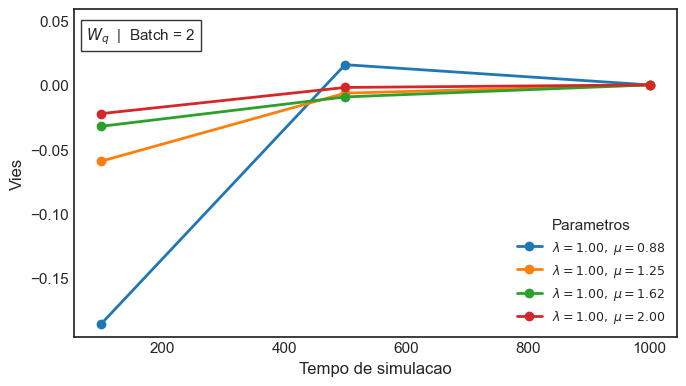

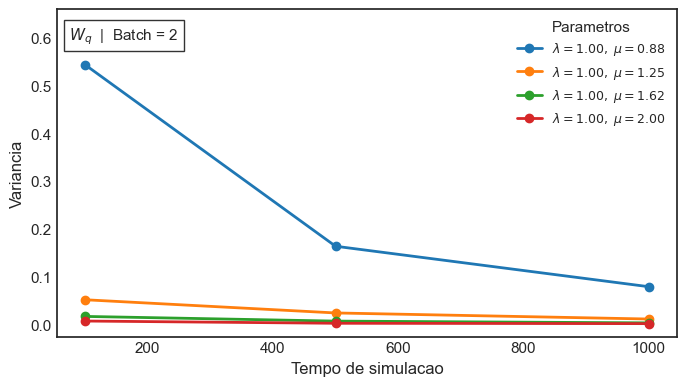

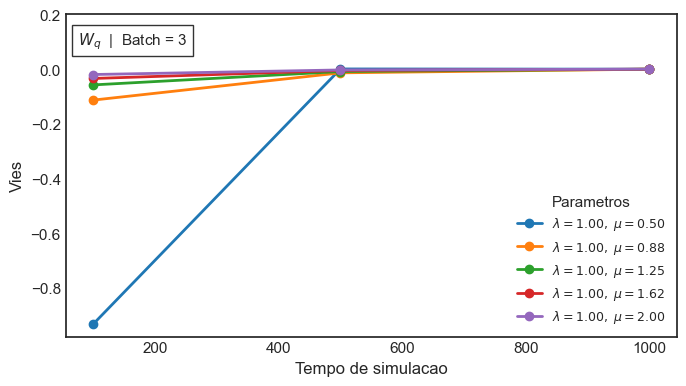

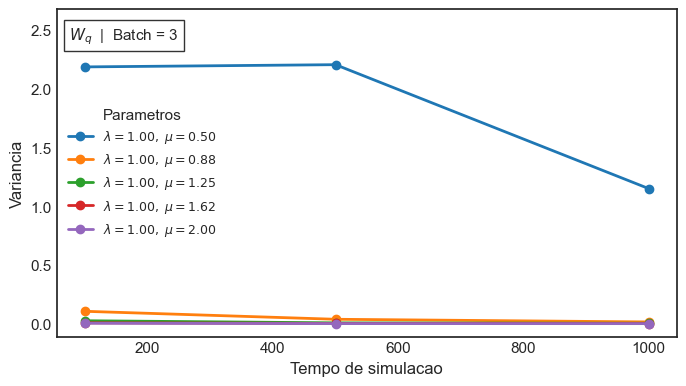

: 

In [ ]:
# Graficos

metrics = ['Wq_mean', 'Wq_var']

for batch, dfb in df_plot.groupby('batch'):

    for metric in metrics:

        fig, ax = plt.subplots()

        for (l, m), sub in dfb.groupby(['lambda', 'mu']):

            sub = sub.sort_values('tmax')

            if sub['Rho_mean'].max() >= 0.98:
                continue

            y = (
                sub[metric] - sub[metric].iloc[-1]
                if 'mean' in metric else
                sub[metric]
            )

            ax.plot(
                sub['tmax'],
                y,
                marker='o',
                label=fr'$\lambda={l:.2f},\ \mu={m:.2f}$'
            )

        titulo, ylabel = metric_info[metric]

        ax.set_xlabel('Tempo de simulacao')
        ax.set_ylabel(ylabel)

        ymin, ymax = ax.get_ylim()
        ax.set_ylim(ymin, ymax + (ymax - ymin) * 0.15)

        titulo, ylabel = metric_info[metric]

        ax.text(
            0.02,
            0.95,
            fr'{titulo}  |  Batch = {batch}',
            transform=ax.transAxes,
            va='top',
            bbox=dict(facecolor='white', alpha=0.8)
        )   

        ax.legend(title='Parametros')

        plt.tight_layout()
        plt.show()

In [ ]:

plt.style.use('ggplot')  # estilos prontos: ggplot, seaborn-v0_8, bmh...

metrics = [
    'Wq_mean',# 'Lq_mean', 'Rho_mean',
    'Wq_var', #'Lq_var', 'Rho_var'
]

for batch, dfb in df_plot.groupby('batch'):

    for metric in metrics:

        fig, ax = plt.subplots(figsize=(7,4))

        for (l, m), sub in (
            dfb.sort_values('tmax')
               .groupby(['lambda', 'mu'])
        ):

            if sub['Rho_mean'].max() < 0.98:

                ax.plot(
                    sub['tmax'],
                    sub[metric],
                    marker='o',
                    linewidth=2,
                    markersize=5,
                    label=fr'$\lambda={l},\ \mu={m}$'
                )

        ax.set_title(f'{metric} | batch={batch}', fontsize=14)
        ax.set_xlabel('tmax', fontsize=11)
        ax.set_ylabel(metric, fontsize=11)

        ax.legend(
            title='Parametros',
            fontsize=9,
            title_fontsize=10,
            loc='best',
            frameon=True,
            fancybox=True,
            shadow=False,
            ncol=2
        )

        ax.grid(alpha=0.3)

        plt.tight_layout()
        plt.show()